In [17]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
df = pd.read_csv(os.path.join(os.getcwd(), "reports", "results.tsv"), sep="\t")
upward_metrics = ["r2_mean"]
downward_metrics = ["smape_mean"]
metrics = upward_metrics + downward_metrics

for key in metrics:
    df[key] = pd.to_numeric(df[key], errors="coerce")

df["vram_gb"] = pd.to_numeric(df["vram_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Total experiments: 31
Columns: ['agentic_model', 'branch', 'commit', 'smape_mean', 'smape_bram', 'smape_dsp', 'smape_ff', 'smape_lut', 'smape_cycles', 'smape_interval', 'r2_mean', 'r2_bram', 'r2_dsp', 'r2_ff', 'r2_lut', 'r2_cycles', 'r2_interval', 'rmse_bram', 'rmse_dsp', 'rmse_ff', 'rmse_lut', 'rmse_cycles', 'rmse_interval', 'num_epochs', 'platform', 'vram_gb', 'time_budget', 'status', 'description']


,agentic_model,branch,commit,smape_mean,smape_bram,smape_dsp,smape_ff,smape_lut,smape_cycles,smape_interval,...,rmse_ff,rmse_lut,rmse_cycles,rmse_interval,num_epochs,platform,vram_gb,time_budget,status,description
0,claude-sonnet-4-6,agent-20260404T013622Z,64fe5b3,12.9477,14.4764,12.3696,9.8167,13.6920,9.8018,17.5297,...,5.10,24.91,396713.63,193555.26,"{""bram"": 6, ""dsp"": 6, ""ff"": 6, ""lut"": 6, ""cycl...",AMD Radeon RX 7800 XT,0.09,3600.0,BASELINE,Unmodified baseline: 6 separate GNN predictors...
1,claude-sonnet-4-6,agent-20260404T013622Z,fae1aa4,14.7218,13.0744,11.2813,10.7063,13.9521,19.2819,20.0347,...,2.80,17.52,295400.90,148314.96,"{""all"": 39}",AMD Radeon RX 7800 XT,0.08,3600.0,KEEP,"Joint 6-target model (1 group, full 3600s budg..."
2,claude-sonnet-4-6,agent-20260404T013622Z,fa2a306,19.6277,12.9773,11.1087,8.5971,12.1852,37.8774,35.0203,...,3.64,21.00,318585.97,158868.25,"{""all"": 40}",AMD Radeon RX 7800 XT,0.08,3600.0,DISCARD,Joint model with direct SMAPE loss. Much worse...
3,claude-sonnet-4-6,agent-20260404T013622Z,fbad451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{""all"": 37}",AMD Radeon RX 7800 XT,0.00,3600.0,CRASH,Log-MAE joint model — crashed at epoch 37 (AMD...
4,claude-sonnet-4-6,agent-20260404T013622Z,97f8d44,20.2073,12.9801,9.9309,10.1445,14.9637,35.6146,37.6098,...,2.82,17.97,375901.72,188156.02,"{""all"": 40}",AMD Radeon RX 7800 XT,0.09,3600.0,DISCARD,Log-MAE + empty_cache workaround. CYCLES/INTER...


In [19]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_baseline = counts.get("BASELINE", 0)
n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD     14
KEEP         8
CRASH        7
BASELINE     2

Keep rate: 8/22 = 36.4%


Show all KEPT experiments.

In [20]:
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    scores = [row[key] for key in metrics]
    desc = row["description"]
    print(
        f"  #{i:3d}  {', '.join(f'{key}={score:.4f}' for key, score in zip(metrics, scores))}  vram={row['vram_gb']:.1f}GB  {desc}")

KEPT experiments (8 total):

  #  1  r2_mean=0.6877, smape_mean=14.7218  vram=0.1GB  Joint 6-target model (1 group, full 3600s budget → 39 epochs), AdamW lr=1e-3 weight_decay=1e-4, CosineAnnealingWarmRestarts T_0=20, per-target-averaged MSLE loss
  #  8  r2_mean=0.6975, smape_mean=14.5388  vram=0.1GB  HLS-derived per-node features (6 new): hls_multiplier_est/uses_lut_table/pipelined + log1p variants. CYCLES/INTERVAL SMAPE improved dramatically (16.8%/17.4% vs 19.3%/20.0%). FF/LUT SMAPE regressed (13.3%/16.0% vs 10.7%/14.0%) but R2 improved. Both mean metrics improved.
  # 12  r2_mean=0.7970, smape_mean=6.6061  vram=0.4GB  Transformer encoder replacing GNN: Pre-LN 3-layer 4-head d_model=128 dim_ff=256, global CLS token, learned positional enc, 473K params, 145 epochs (3.7x more than GNN). Mean SMAPE 14.54->6.61 (-55%), mean R2 0.698->0.797. All 6 targets massively improved. CYCLES/INTERVAL RMSE slightly regressed (outlier tail harder for Transformer) but SMAPE halved on both. Clear best

Track how the best (kept) scores evolve as experiments progress.

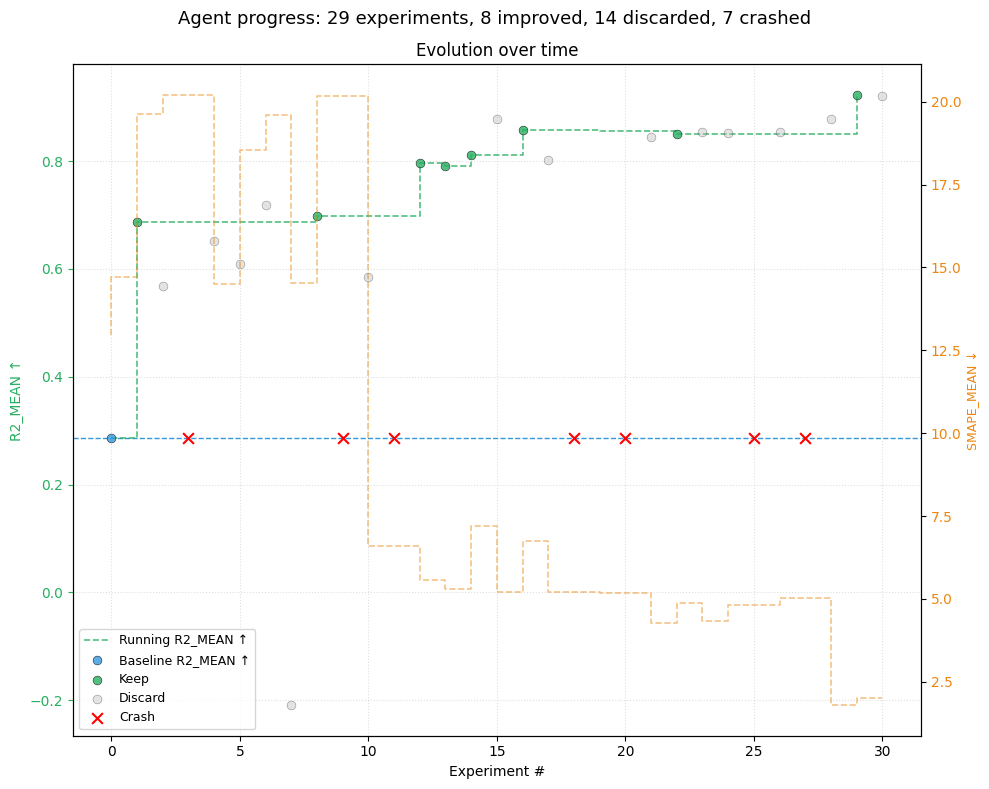

In [23]:
valid = df[df["status"] != "CRASH"].copy()
kept = valid[valid["status"].isin(["BASELINE", "KEEP"])]  # include baseline in the kept set for plotting
crashes = df[df["status"] == "CRASH"]

main_metric = upward_metrics[0]
secondary_metric = downward_metrics[0]

main_trend = "↑" if main_metric in upward_metrics else "↓"
secondary_trend = "↑" if secondary_metric in upward_metrics else "↓"

baseline_scores = valid.loc[0, main_metric]
running_best = kept[main_metric].cummax().reindex(valid.index).ffill()

STATUS_COLOR = {
    "BASELINE": "#3498db",
    "KEEP": "#27ae60",
    "DISCARD": "#bbbbbb",
    "MAIN": "#27ae60",
    "SECONDARY": "#ed8611"
}
DOT_SIZE = 40

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
fig.suptitle(
    f"Agent progress: {len(df[df['status'] != 'BASELINE'])} experiments, "
    f"{n_keep} improved, {n_discard} discarded, {n_crash} crashed",
    fontsize=13,
)

ax_ratio = ax.twinx()
ax_ratio.step(
    valid.index, valid[secondary_metric], color=STATUS_COLOR["SECONDARY"],
    linewidth=1.2, linestyle="--", alpha=0.5, zorder=1, label=f"Running {secondary_metric.upper()}"
)
ax_ratio.set_ylabel(f"{secondary_metric.upper()} {secondary_trend}", color=STATUS_COLOR["SECONDARY"], fontsize=9)
ax_ratio.tick_params(axis="y", labelcolor=STATUS_COLOR["SECONDARY"])

ax.step(
    kept.index, kept[main_metric], where="post", linestyle="--",
    color=STATUS_COLOR["MAIN"], linewidth=1.2, alpha=0.8, zorder=3, label=f"Running {main_metric.upper()} {main_trend}"
)
ax.axhline(baseline_scores, color=STATUS_COLOR["BASELINE"], linestyle="--", linewidth=1)

for status, color in STATUS_COLOR.items():
    sel = valid[valid["status"] == status]
    if sel.empty:
        continue
    if status == "BASELINE":
        sel = sel.loc[[0]]  # only plot the first baseline point

    ax.scatter(
        sel.index,
        sel[main_metric],
        s=DOT_SIZE,
        color=color,
        alpha=0.4 if status == "DISCARD" else 0.8,
        edgecolors="black",
        linewidths=0.4,
        zorder=4,
        label=status.capitalize() + (f" {main_metric.upper()} {main_trend}" if status in ["BASELINE"] else "")
    )

if not crashes.empty:
    ax.scatter(
        crashes.index, [baseline_scores] * len(crashes),
        marker="x", color="red", s=60, zorder=5, label="Crash"
    )

ax.tick_params(axis="y", colors=STATUS_COLOR["MAIN"])

ax.set_xlabel("Experiment #")
ax.set_ylabel(f"{main_metric.upper()} {main_trend}", color=STATUS_COLOR["MAIN"])
ax.set_title("Evolution over time")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()